In [1]:
!pip install -q transformers==4.41.2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 77.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 564.3/564.3 kB 26.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 77.1 MB/s eta 0:00:00:00:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
datasets 4.1.1 requires pyarrow>=21.0.0, but you have pyarrow 19.0.1 which is incompatible.
gradio 5.38.1 requires pydantic<2.12,>=2.0, but you have pydantic 2.12.0a1 which is incompatible.


In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/nlp-getting-started/sample_submission.csv
/kaggle/input/nlp-getting-started/train.csv
/kaggle/input/nlp-getting-started/test.csv


In [3]:
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import re

In [4]:
# 设置设备
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"使用设备: {device}")

使用设备: cuda


In [5]:
train_df = pd.read_csv('/kaggle/input/nlp-getting-started/train.csv')
test_df = pd.read_csv('/kaggle/input/nlp-getting-started/test.csv')

In [6]:
train_df

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1
...,...,...,...,...,...
7608,10869,NaN,NaN,Two giant cranes holding a bridge collapse int...,1
7609,10870,NaN,NaN,@aria_ahrary @TheTawniest The out of control w...,1
7610,10871,NaN,NaN,M1.94 [01:04 UTC]?5km S of Volcano Hawaii. htt...,1
7611,10872,NaN,NaN,Police investigating after an e-bike collided ...,1


In [7]:
# 简单的文本清洗
def clean_text(text):
    text = re.sub(r'http\S+', '', text)  # 移除URL
    text = re.sub(r'@\w+|#\w+', '', text)  # 移除@提及和#标签
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # 移除非字母字符
    text = text.lower().strip()  # 转换为小写
    return text
    
train_df['cleaned_text'] = train_df['text'].apply(clean_text)
test_df['cleaned_text'] = test_df['text'].apply(clean_text)

In [8]:
# 创建自定义Dataset
class TweetDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx] if self.labels is not None else -1
        
        encoding = self.tokenizer.encode_plus(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt',
        )
        
        item = {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
        }
        
        if label != -1:
            item['labels'] = torch.tensor(label, dtype=torch.long)
        
        return item

In [9]:
# 训练函数
def train_model(model, train_loader, val_loader, optimizer, scheduler, epochs=3):
    model = model.to(device)
    best_f1 = 0
    train_losses = []
    val_f1_scores = []
    
    for epoch in range(epochs):
        print(f'\nEpoch {epoch + 1}/{epochs}')
        print('-' * 50)
        
        # 训练阶段
        model.train()
        total_loss = 0
        train_pbar = tqdm(train_loader, desc='Training')
        
        for batch in train_pbar:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            
            optimizer.zero_grad()
            
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )
            
            loss = outputs.loss
            total_loss += loss.item()
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            scheduler.step()
            
            train_pbar.set_postfix({'loss': f'{loss.item():.4f}'})
        
        avg_train_loss = total_loss / len(train_loader)
        train_losses.append(avg_train_loss)
        
        # 验证阶段
        val_f1, val_accuracy, all_predictions, all_labels = evaluate_model(model, val_loader)
        val_f1_scores.append(val_f1)
        
        print(f'训练损失: {avg_train_loss:.4f}')
        print(f'验证F1分数: {val_f1:.4f}')
        print(f'验证准确率: {val_accuracy:.4f}')
        
        # 保存最佳模型
        if val_f1 > best_f1:
            best_f1 = val_f1
            torch.save(model.state_dict(), 'best_bert_model.pth')
            print(f'新的最佳模型已保存! F1: {best_f1:.4f}')
    
    return train_losses, val_f1_scores

# 评估函数
def evaluate_model(model, data_loader):
    model.eval()
    predictions = []
    true_labels = []
    total_correct = 0
    total_samples = 0
    
    with torch.no_grad():
        for batch in tqdm(data_loader, desc='Evaluating'):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )
            
            _, preds = torch.max(outputs.logits, dim=1)
            
            predictions.extend(preds.cpu().tolist())
            true_labels.extend(labels.cpu().tolist())
            
            total_correct += (preds == labels).sum().item()
            total_samples += labels.size(0)
    
    accuracy = total_correct / total_samples
    f1 = f1_score(true_labels, predictions, average='weighted')
    
    return f1, accuracy, predictions, true_labels

# 绘制混淆矩阵
def plot_confusion_matrix(true_labels, predictions, class_names=['Non-Disaster', 'Disaster']):
    cm = confusion_matrix(true_labels, predictions)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()
    
    return cm

In [10]:
# 划分训练集和验证集
train_texts, val_texts, train_labels, val_labels = train_test_split(
    train_df['cleaned_text'].values,
    train_df['target'].values,
    test_size=0.2,
    random_state=42,
    stratify=train_df['target']
)

In [11]:
from transformers import DistilBertForSequenceClassification, DistilBertTokenizer

# Load pretrained tokenizer
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

# Load pretrained model with classification head
model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=2  # binary classification: disaster / non-disaster
)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

/usr/local/lib/python3.11/dist-packages/huggingface_hub/file_download.py:945: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [12]:
# 创建数据加载器
train_dataset = TweetDataset(train_texts, train_labels, tokenizer)
val_dataset = TweetDataset(val_texts, val_labels, tokenizer)
test_dataset = TweetDataset(test_df['cleaned_text'].values, None, tokenizer)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

# 设置优化器和学习率调度器
optimizer = AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)
total_steps = len(train_loader) * 3  # epochs
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=total_steps)


In [13]:
# 训练模型
print("开始训练BERT模型...")
train_losses, val_f1_scores = train_model(
    model, train_loader, val_loader, optimizer, scheduler, epochs=20
)

开始训练BERT模型...

Epoch 1/20
--------------------------------------------------


Evaluating: 100%|██████████| 96/96 [00:03<00:00, 28.50it/s]


训练损失: 0.4517
验证F1分数: 0.8290
验证准确率: 0.8326
新的最佳模型已保存! F1: 0.8290

Epoch 2/20
--------------------------------------------------


Evaluating: 100%|██████████| 96/96 [00:03<00:00, 28.37it/s]


训练损失: 0.3383
验证F1分数: 0.8332
验证准确率: 0.8332
新的最佳模型已保存! F1: 0.8332

Epoch 3/20
--------------------------------------------------


...

训练损失: 0.0682
验证F1分数: 0.8075
验证准确率: 0.8076

Epoch 19/20
--------------------------------------------------


Evaluating: 100%|██████████| 96/96 [00:03<00:00, 28.51it/s]


训练损失: 0.0612
验证F1分数: 0.8185
验证准确率: 0.8188

Epoch 20/20
--------------------------------------------------


Evaluating: 100%|██████████| 96/96 [00:03<00:00, 28.63it/s]

训练损失: 0.0436
验证F1分数: 0.8110
验证准确率: 0.8109


In [14]:
# 加载最佳模型进行最终评估
print("\n加载最佳模型进行最终评估...")
model.load_state_dict(torch.load('best_bert_model.pth'))
final_f1, final_accuracy, predictions, true_labels = evaluate_model(model, val_loader)

print(f"\n最终评估结果:")
print(f"F1分数: {final_f1:.4f}")
print(f"准确率: {final_accuracy:.4f}")


加载最佳模型进行最终评估...


Evaluating: 100%|██████████| 96/96 [00:03<00:00, 28.48it/s]


最终评估结果:
F1分数: 0.8402
准确率: 0.8418



分类报告:
              precision    recall  f1-score   support

Non-Disaster       0.83      0.91      0.87       869
    Disaster       0.86      0.76      0.80       654

    accuracy                           0.84      1523
   macro avg       0.84      0.83      0.84      1523
weighted avg       0.84      0.84      0.84      1523


混淆矩阵:


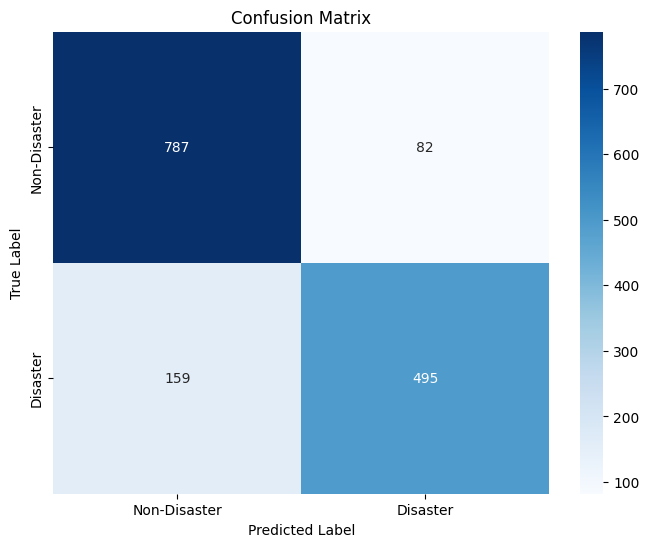

[[787  82]
 [159 495]]

生成测试集预测...


Predicting: 100%|██████████| 204/204 [00:07<00:00, 28.60it/s]


In [15]:
# 生成分类报告
print("\n分类报告:")
print(classification_report(true_labels, predictions, target_names=['Non-Disaster', 'Disaster']))

# 绘制混淆矩阵
print("\n混淆矩阵:")
cm = plot_confusion_matrix(true_labels, predictions)
print(cm)

# 生成测试集预测
print("\n生成测试集预测...")
model.eval()
test_predictions = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc='Predicting'):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        
        _, preds = torch.max(outputs.logits, dim=1)
        test_predictions.extend(preds.cpu().tolist())




提交文件已生成! 预测分布:
target
0    2103
1    1160
Name: count, dtype: int64


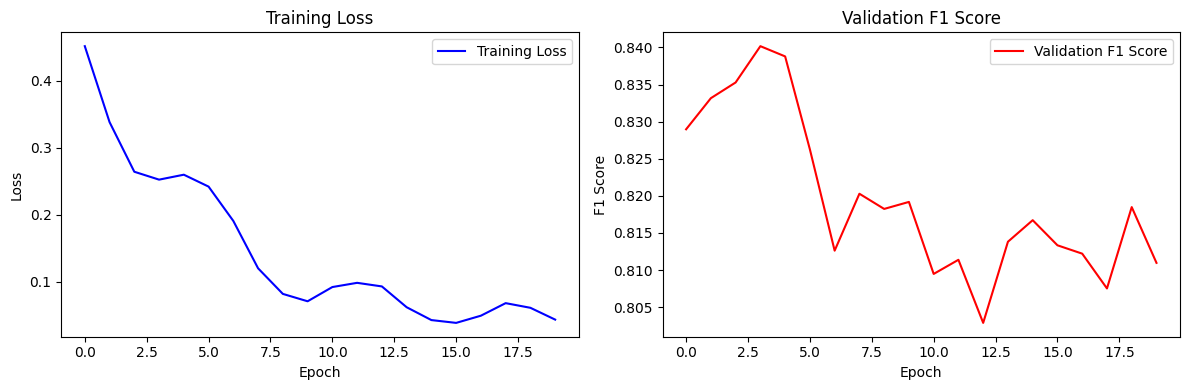

In [16]:
# 创建提交文件
submission = pd.DataFrame({
    'id': test_df['id'],
    'target': test_predictions
})

submission.to_csv('submission.csv', index=False)
print(f"\n提交文件已生成! 预测分布:")
print(submission['target'].value_counts())

# 绘制训练过程
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, 'b-', label='Training Loss')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(val_f1_scores, 'r-', label='Validation F1 Score')
plt.title('Validation F1 Score')
plt.xlabel('Epoch')
plt.ylabel('F1 Score')
plt.legend()

plt.tight_layout()
plt.show()